In [1]:
import json, glob
import pandas as pd

rows = []
for p in glob.glob("../data/raw/*.jsonl"):
    with open(p, encoding="utf-8") as f:
        rows += [json.loads(line) for line in f]

df = pd.DataFrame(rows)
df["created_at"] = pd.to_datetime(df["created_at"])
df["closed_at"] = pd.to_datetime(df["closed_at"])
print(df.shape)
df.head()

(12269, 14)


,repo,number,title,body,labels,state,state_reason,created_at,closed_at,comments,reactions_total,author,author_association,url
0,huggingface/transformers,49267,Gemma 4 `response_template` parses reasoning i...,The `response_template` added to the Gemma 4 i...,[],open,NaN,2026-10-02 15:52:45+00:00,NaT,0,0,albertvillanova,MEMBER,https://github.com/huggingface/transformers/is...
1,huggingface/transformers,49261,`generate()` with a static cache: host-side in...,### System Info\n\n`transformers` 5.18.0 (unch...,[],open,NaN,2026-10-02 13:19:45+00:00,NaT,0,0,dacorvo,CONTRIBUTOR,https://github.com/huggingface/transformers/is...
2,huggingface/transformers,49253,ImageTextToTextPipeline warns about generation...,**Verification status (2026-10-02):** reproduc...,[],open,NaN,2026-10-02 09:01:49+00:00,NaT,2,1,jr2804,NONE,https://github.com/huggingface/transformers/is...
3,huggingface/transformers,49252,AutoTokenizer with tokenizer_class=LlamaTokeni...,### System Info\n\ntransformers: 5.8.1\ntokeni...,[bug],open,NaN,2026-10-02 08:00:48+00:00,NaT,2,0,kangzhengyang,NONE,https://github.com/huggingface/transformers/is...
4,huggingface/transformers,49241,[serge] integration failure triage - 2026-10-01,<!-- serge-triage-run:integration-failure-tria...,[],open,NaN,2026-10-01 22:13:52+00:00,NaT,0,0,github-actions[bot],CONTRIBUTOR,https://github.com/huggingface/transformers/is...


In [2]:
df["repo"].value_counts()

repo
microsoft/vscode             5074
scikit-learn/scikit-learn    2651
pandas-dev/pandas            2475
huggingface/transformers     2069
Name: count, dtype: int64

In [3]:
df.isna().mean().sort_values(ascending=False)

closed_at             0.310050
state_reason          0.304018
title                 0.000000
body                  0.000000
repo                  0.000000
number                0.000000
state                 0.000000
labels                0.000000
created_at            0.000000
comments              0.000000
reactions_total       0.000000
author                0.000000
author_association    0.000000
url                   0.000000
dtype: float64

In [4]:
(df["body"].str.len() == 0).mean()      # share of empty bodies

np.float64(0.004238324231803733)

In [5]:
df["labels"].apply(len).eq(0).mean()    # share with NO labels

np.float64(0.23848724427418697)

In [6]:
df.duplicated(subset=["repo", "number"]).sum()   # should be 0

np.int64(1)

In [7]:
# Remove duplicate GitHub issues
df = df.drop_duplicates(subset=["repo", "number"], keep="first").copy()

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated(subset=["repo", "number"]).sum())

Shape after removing duplicates: (12268, 14)
Remaining duplicates: 0


In [8]:
labels_long = df.explode("labels")
top = labels_long.groupby(["repo", "labels"]).size().reset_index(name="n")
for repo, g in top.groupby("repo"):
    print(repo)
    print(g.sort_values("n", ascending=False).head(25).to_string(index=False))
    print()

huggingface/transformers
                    repo                labels    n
huggingface/transformers                   bug 1113
huggingface/transformers       Feature request  210
huggingface/transformers             New model   57
huggingface/transformers                   WIP   31
huggingface/transformers                Vision   19
huggingface/transformers      Good First Issue   17
huggingface/transformers       Code agent slop   17
huggingface/transformers     Good Second Issue   16
huggingface/transformers                 Audio   16
huggingface/transformers               for_v5?    9
huggingface/transformers  Good Difficult Issue    5
huggingface/transformers                 Usage    5
huggingface/transformers               trainer    4
huggingface/transformers               Whisper    4
huggingface/transformers            Should Fix    3
huggingface/transformers               kernels    2
huggingface/transformers contributions-welcome    2
huggingface/transformers       Tensor P

In [9]:
df["title_len"] = df["title"].str.len()
df["body_len"] = df["body"].str.len()
df["has_code_block"] = df["body"].str.contains("```", regex=False)
df["has_traceback"] = df["body"].str.contains(
    r"Traceback \(most recent call last\)|Exception in thread|\bError:", regex=True
)

df[["title_len", "body_len"]].describe()
df.groupby("repo")[["has_code_block", "has_traceback"]].mean()

,has_code_block,has_traceback
repo,,
huggingface/transformers,0.621556,0.149348
microsoft/vscode,0.398581,0.037650
pandas-dev/pandas,0.751111,0.098990
scikit-learn/scikit-learn,0.526217,0.134289


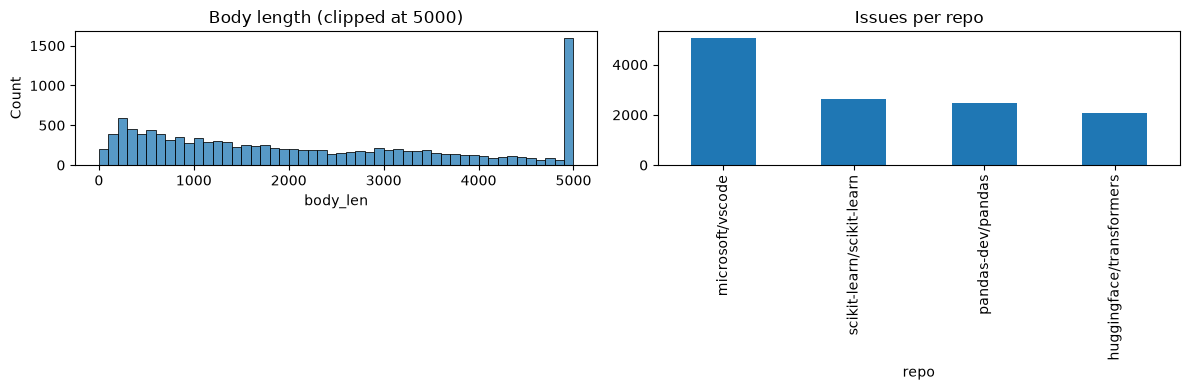

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["body_len"].clip(upper=5000), bins=50, ax=ax[0])
ax[0].set_title("Body length (clipped at 5000)")
df["repo"].value_counts().plot(kind="bar", ax=ax[1], title="Issues per repo")
plt.tight_layout()
plt.savefig("../docs_eda_overview.png", dpi=150)

In [11]:
df["days_to_close"] = (df["closed_at"] - df["created_at"]).dt.total_seconds() / 86400
df["days_to_close"].describe()
df[["comments", "reactions_total", "days_to_close"]].corr(method="spearman")

,comments,reactions_total,days_to_close
comments,1.000000,0.138435,0.482429
reactions_total,0.138435,1.000000,0.134163
days_to_close,0.482429,0.134163,1.000000


<Axes: xlabel='created_at'>

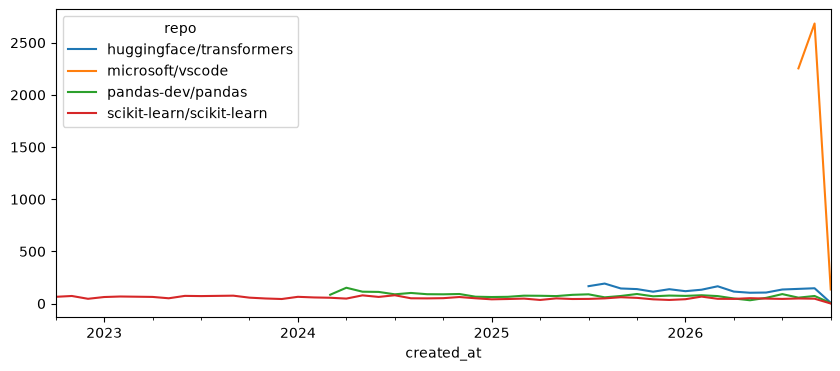

In [12]:
df.set_index("created_at").groupby("repo").resample("ME").size().unstack(0).plot(figsize=(10, 4))